# 用分布生成绥化市区前 165 名的成绩单，并检验它准不准

上一个 notebook 解释了两个假设：
- 绥化市区 4923 人，**629 分以下**大致 N(533.5, 36.3²)；
- **629 分及以上**大致 N(579, 19²)（σ 借自大庆，接缝处人数连续）。

这个 notebook 反过来用它们：**把分布当作发牌机，直接生成前 165 名的成绩单**（名次 → 分数），
再拿几条「已知事实」去核对，看这套估算准不准。

已知的事实（来自当事人的记忆与资料）：

1. 608 分的同学是市区第 **105** 名；
2. 市区第 1 名 **647** 分，第 2 名 **646** 分（第 3 名及以后不确定，可能是 642 分左右，**不钉死**）；
3. 615 分大约是第 **60** 名，604 分大约是第 **125** 名。

注意区分：**1、2 用来「钉死」成绩单的几个点；3 只用来「检验」**，不参与生成。

## 1 先重建上一个 notebook 的分布

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Hiragino Sans GB', 'Heiti TC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

N = 4923                                   # 绥化市区考生
(x1, n1), (x2, n2) = (571, 742), (600, 165)   # 两个节点
z1, z2 = norm.isf(n1 / N), norm.isf(n2 / N)
sig_a = (x2 - x1) / (z2 - z1); mu_a = x1 - sig_a * z1      # → N(533.5, 36.3²)
SIG_B, X0 = 19, 629                                          # 629 分及以上：σ=19
mu_b = X0 - SIG_B * (X0 - mu_a) / sig_a                      # 接缝处连续 → μ=579

def single(x):  return N * norm.sf((np.asarray(x, float) - mu_a) / sig_a)
def two_seg(x):
    x = np.asarray(x, float)
    return np.where(x <= X0, single(x), N * norm.sf((x - mu_b) / SIG_B))

print(f'N({mu_a:.1f}, {sig_a:.1f}²)；{X0} 分及以上 N({mu_b:.0f}, {SIG_B}²)')

N(533.5, 36.3²)；629 分及以上 N(579, 19²)


## 2 怎么从分布生成「第 r 名考多少分」

「第 r 名」的意思是：全市有 r 个人分数 ≥ 他。分布给出了「≥ x 的人数」函数 f(x)，
所以第 r 名的分数就是方程 **f(x) = r − 0.5** 的解（减 0.5 是「半个名次」修正，让每个名次落在它所占区间的中点）。
解出来再四舍五入到整数分。这样得到的是**分布意义下最典型的成绩单**，不带随机波动。

In [2]:
def score_of_rank(r, f=two_seg):
    return brentq(lambda x: float(f(x)) - (r - 0.5), 540, 700)

ranks = np.arange(1, 166)
model = np.array([round(score_of_rank(r)) for r in ranks])   # 纯分布生成
pd.DataFrame({'名次': [1, 2, 3, 4, 5, 10, 20, 40, 60, 80, 105, 125, 165],
              '分布推算分数': [model[r-1] for r in [1, 2, 3, 4, 5, 10, 20, 40, 60, 80, 105, 125, 165]]}).set_index('名次').T

名次,1,2,3,4,5,10,20,40,60,80,105,125,165
分布推算分数,650,644,641,640,638,634,629,621,615,611,607,604,600


## 3 钉死已知的点（第 1、2、105 名）

已知第 1 名 647、第 2 名 646、第 105 名 608；第 3 名起不知道，由分布给出。把这几个点替换进去，再保持名次单调（分数不随名次上升而升高）：

In [3]:
sheet = model.copy()
src = np.array(['分布推算'] * 165, dtype=object)
for r, s in [(1, 647), (2, 646), (105, 608)]:
    sheet[r-1] = s; src[r-1] = '已知'
# 保持单调：105 名之前不低于 608，105 名之后不高于 608
for i in range(165):
    r = i + 1
    if r < 105 and src[i] != '已知': sheet[i] = max(sheet[i], 608)
    if r > 105 and src[i] != '已知': sheet[i] = min(sheet[i], 608)
assert (np.diff(sheet) <= 0).all(), '名次非单调'
out = pd.DataFrame({'名次': ranks, '分数': sheet, '依据': src})
out.to_csv('2004年中考绥化市区前165名成绩单（分布推算）.csv', index=False, encoding='utf-8-sig')
print('已写出：2004年中考绥化市区前165名成绩单（分布推算）.csv')
out.iloc[[0, 1, 2, 3, 4, 9, 19, 39, 59, 79, 104, 124, 164]].set_index('名次').T

已写出：2004年中考绥化市区前165名成绩单（分布推算）.csv


名次,1,2,3,4,5,10,20,40,60,80,105,125,165
分数,647,646,641,640,638,634,629,621,615,611,608,604,600
依据,已知,已知,分布推算,分布推算,分布推算,分布推算,分布推算,分布推算,分布推算,分布推算,已知,分布推算,分布推算


## 4 检验：没有参与生成的事实，分布预测得准吗？

把「名次」换成「人数」：第 105 名、分数 608，意思是「≥ 608 分的人数约 105」。
分布预测「≥ s 分的人数」，整数分的修正是取 f(s − 0.5)。对比：

| 检验 | 说明 |
|---|---|
| ≥608 → 105 | 已知（但已被钉入成绩单，这里是独立再验证：模型自己预测多少？） |
| ≥615 → 约 60 | 只用来检验 |
| ≥604 → 约 125 | 只用来检验 |
| ≥646 → 至少 2（很可能就是 2） | 第 1、2 名；第 3 名不确定，若更低则恰为 2 |
| ≥647 → 1 | 只有第 1 名 |

「单段」= 不压缩（629 以上继续 N(533.5, 36.3²)）；「两段」= 文章采用的假设。

In [4]:
checks = [('≥608', 608, 105), ('≥615', 615, 60), ('≥604', 604, 125), ('≥646', 646, 2), ('≥647', 647, 1)]
rows = []
for name, s, obs in checks:
    p1, p2 = float(single(s - .5)), float(two_seg(s - .5))
    rows.append({'检验': name, '已知人数': obs, '单段预测': round(p1, 1), '两段预测': round(p2, 1),
                 '两段偏差(σ)': round((obs - p2) / np.sqrt(p2), 1), '单段偏差(σ)': round((obs - p1) / np.sqrt(p1), 1)})
chk = pd.DataFrame(rows).set_index('检验')
chk

,已知人数,单段预测,两段预测,两段偏差(σ),单段偏差(σ)
检验,,,,,
≥608,105,102.3,102.3,0.3,0.3
≥615,60,63.3,63.3,-0.4,-0.4
≥604,125,132.6,132.6,-0.7,-0.7
≥646,2,5.0,1.2,0.8,-1.4
≥647,1,4.6,0.9,0.1,-1.7


**读法：** 「偏差(σ)」= (已知 − 预测) / √预测，大致是「差了几个泊松标准差」，绝对值 < 2 算正常随机波动。

**中间段（600–615 分）预测得很准**：608 分预测 ≈102（已知 105）、615 分预测 ≈63（已知 ≈60）、604 分预测 ≈133（已知 ≈125），误差都在 6% 以内。
这一段本来就是用 571、600 两个节点内插出来的，所以准是预期之中——但这三条已知事实**没有**被用来定参数，所以它们是真正的外部验证。

**最顶端也吻合，而且能区分两个模型：** 已知 1 人 ≥647、至少 2 人 ≥646（如果第 3 名确实比 646 低，就恰好是 2 人）。
两段模型预测 ≈0.9 人 ≥647、≈1.2 人 ≥646，与已知相差都在 1σ 以内；
**单段（不压缩）模型预测 ≈4.6 人 ≥647、≈5 人 ≥646，明显偏多**（≥647 偏差 −1.7σ，≥646 偏差 −1.3σ）。
这是对「629 分以上要压缩」这个假设的一条间接支持：如果不压缩，前 5 名的分数应该比 647、646 还要高（单段分布给出的第 1 名约 683 分）。
但要注意，这只有 2 个人，只能说「与压缩一致、与不压缩不一致」，不是严格证明。

## 5 出图

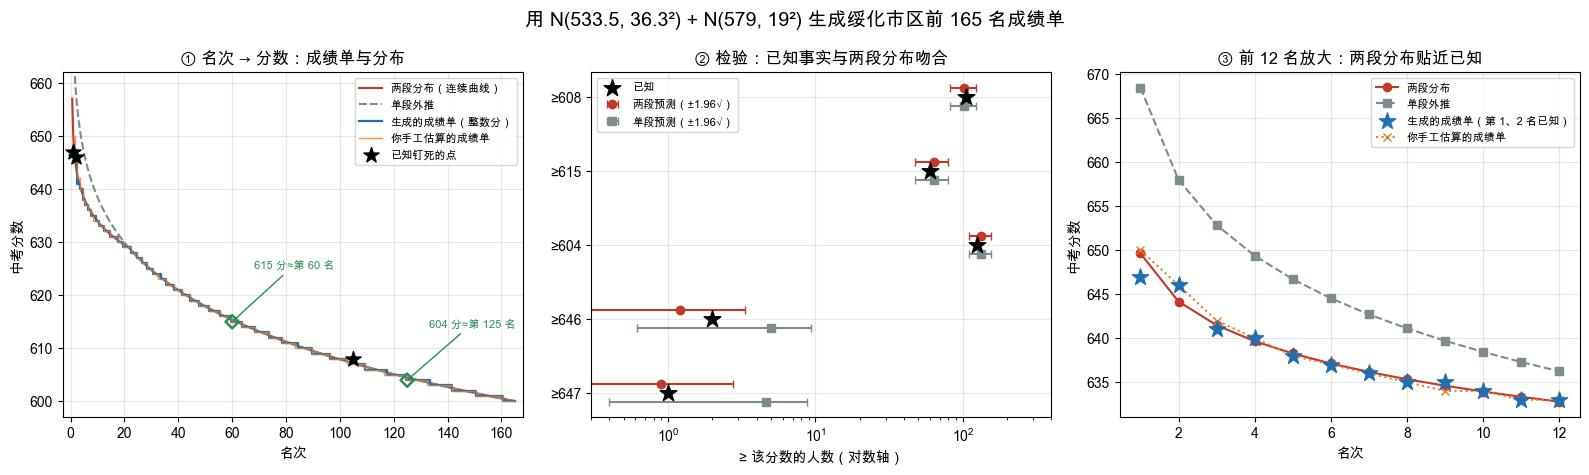

In [5]:
old_path = next((p for p in [Path('2004年中考绥化市区前165名成绩单.csv'), Path('content/kao/2004年中考绥化市区前165名成绩单.csv')] if p.exists()), None)
old = pd.read_csv(old_path) if old_path else None

fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
BLUE, RED, GREY, ORG, GRN = '#1f6fb2', '#c0392b', '#7f8c8d', '#e67e22', '#2c8c5a'

# ① 名次 → 分数
a = ax[0]
rr = np.linspace(.6, 165, 400)
a.plot(rr, [score_of_rank(r) for r in rr], color=RED, label='两段分布（连续曲线）')
a.plot(rr, [score_of_rank(r, single) for r in rr], '--', color=GREY, label='单段外推')
a.step(ranks, sheet, where='mid', color=BLUE, lw=1.6, label='生成的成绩单（整数分）')
if old is not None:
    a.step(old['名次'], old['分数'], where='mid', color=ORG, lw=1, alpha=.8, label='你手工估算的成绩单')
known = out[out['依据'] == '已知']
a.scatter(known['名次'], known['分数'], marker='*', s=130, color='k', zorder=5, label='已知钉死的点')
for r, s, t in [(60, 615, '615 分≈第 60 名'), (125, 604, '604 分≈第 125 名')]:
    a.scatter([r], [s], marker='D', s=45, facecolor='none', edgecolor=GRN, lw=1.8, zorder=5)
    a.annotate(t, (r, s), (r + 8, s + 10), fontsize=8, color=GRN, arrowprops=dict(arrowstyle='-', color=GRN))
a.set_ylim(597, 662); a.set_xlim(-3, 168)
a.set_xlabel('名次'); a.set_ylabel('中考分数'); a.set_title('① 名次 → 分数：成绩单与分布')
a.legend(fontsize=8); a.grid(alpha=.3)

# ② 检验：已知 vs 预测（对数轴，误差线 = ±√预测）
a = ax[1]
y = np.arange(len(chk))[::-1]
a.errorbar(chk['两段预测'], y + .12, xerr=1.96 * np.sqrt(chk['两段预测']), fmt='o', color=RED, capsize=3, label='两段预测（±1.96√）')
a.errorbar(chk['单段预测'], y - .12, xerr=1.96 * np.sqrt(chk['单段预测']), fmt='s', color=GREY, capsize=3, label='单段预测（±1.96√）')
a.scatter(chk['已知人数'], y, marker='*', s=160, color='k', zorder=5, label='已知')
a.set_yticks(y); a.set_yticklabels(chk.index); a.set_xscale('log')
a.set_xlabel('≥ 该分数的人数（对数轴）'); a.set_title('② 检验：已知事实与两段分布吻合')
a.set_xlim(.3, 400); a.legend(fontsize=8, loc='upper left'); a.grid(alpha=.3)

# ③ 前 12 名放大
a = ax[2]
a.plot(ranks[:12], [score_of_rank(r) for r in ranks[:12]], 'o-', color=RED, label='两段分布')
a.plot(ranks[:12], [score_of_rank(r, single) for r in ranks[:12]], 's--', color=GREY, label='单段外推')
a.scatter(ranks[:12], sheet[:12], marker='*', s=150, color=BLUE, zorder=4, label='生成的成绩单（第 1、2 名已知）')
if old is not None:
    a.plot(old['名次'][:12], old['分数'][:12], 'x:', color=ORG, label='你手工估算的成绩单')
a.set_xlabel('名次'); a.set_ylabel('中考分数'); a.set_title('③ 前 12 名放大：两段分布贴近已知')
a.legend(fontsize=8); a.grid(alpha=.3)

fig.suptitle('用 N(533.5, 36.3²) + N(579, 19²) 生成绥化市区前 165 名成绩单', fontsize=14)
fig.tight_layout()
fig.savefig('2004年中考绥化市区前165名成绩单（分布推算）.png', dpi=150)
plt.show()

## 6 和手工成绩单对比

In [6]:
def count_ge(df, col, s): return int((df[col] >= s).sum())
cmp_rows = []
for s, known_n in [(647, 1), (646, 2), (615, 60), (608, 105), (604, 125)]:
    row = {'分数 ≥': s, '已知': known_n, '分布推算成绩单': count_ge(out, '分数', s)}
    if old is not None: row['你手工估算'] = count_ge(old, '分数', s)
    cmp_rows.append(row)
pd.DataFrame(cmp_rows).set_index('分数 ≥')

,已知,分布推算成绩单,你手工估算
分数 ≥,,,
647,1,1,1
646,2,2,2
615,60,63,63
608,105,105,102
604,125,133,132


## 7 结论与边界

1. **能说**：在 600–615 分这一段，分布对「某个分数大约第几名」的预测与三条已知事实相差不超过约 6%；
   用它生成的成绩单（尤其是第 40–165 名）有可靠的统计依据。
2. **顶端也吻合**：已知第 1 名 647、第 2 名 646，两段模型预测 ≥647 约 0.9 人、≥646 约 1.2 人，吻合；不压缩的单段模型预测约 5 人，偏多。
   这支持「629 分以上要压缩」，但样本只有 2 人，不能当作证明。第 3 名起顶端的具体分数（例如 642）只是分布的典型值，并不确定。
3. **这份成绩单是「分布意义下最典型」的**：没有随机波动，所以并列人数（同分的人数）是由分布的密度决定的，
   真实成绩单会有随机的并列多少，不应当逐名次去解读。
4. 「已知」的 3 个点（第 1、2 名与第 105 名）以外的所有名次，分数都来自分布，而不是记忆或资料。